In [12]:
# ==========================================
# BLOCK 1: INSTALL LIBRARIES
# ==========================================
!pip install -q transformers datasets peft accelerate evaluate scikit-learn seaborn matplotlib

Block 2: Load Dataset & Tokenizer

In [1]:
# ==========================================
# BLOCK 2: LOAD DATASET & PREPARE TOKENIZER (CORRECTED)
# ==========================================
import torch
import numpy as np
import pandas as pd
import time
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'})")

# 1. Load the SST-2 Sentiment Dataset (Updated with full namespace)
dataset = load_dataset("nyu-mll/glue", "sst2")
print("\nDataset structure:")
print(dataset)

# 2. Tokenizer setup
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Sample subsets to train and evaluate within reasonable Colab limits
train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(4000))
eval_dataset = tokenized_datasets["validation"].shuffle(seed=42).select(range(872))

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("\nTokenization and dataset splits ready!")

Using device: cuda (Tesla T4)


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


Tokenization and dataset splits ready!


Block 3: Metrics & Evaluation Helper Functions

In [3]:
# ==========================================
# BLOCK 3: EVALUATION & PROFILING HELPERS
# ==========================================
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary")
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def count_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_pct = (trainable_params / total_params) * 100
    return trainable_params, total_params, trainable_pct

# Storage list for benchmark results
benchmark_results = []

print("Evaluation and profiling helpers are ready!")

Evaluation and profiling helpers are ready!


Block 4: Full-Bit Fine-Tuning Baseline

In [7]:
# ==========================================
# BLOCK 4: FULL-BIT FINE-TUNING (UPDATED)
# ==========================================
import time
import torch
import numpy as np
from transformers import TrainingArguments, Trainer, AutoModelForSequenceClassification

print("--- Starting Full-Bit Fine-Tuning ---")

# Reset GPU memory stats
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Load fresh base model
full_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
trainable_p, total_p, trainable_pct = count_parameters(full_model)

training_args_full = TrainingArguments(
    output_dir="./results_full",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    report_to="none"
)

trainer_full = Trainer(
    model=full_model,
    args=training_args_full,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer, # <--- FIXED: 'tokenizer' is now 'processing_class'
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Measure training time
start_time = time.time()
trainer_full.train()
training_time = time.time() - start_time

# Measure memory and final validation metrics
peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)  # In MB
eval_metrics = trainer_full.evaluate()

# Predictions for confusion matrix
raw_preds = trainer_full.predict(eval_dataset)
full_preds = np.argmax(raw_preds.predictions, axis=-1)

benchmark_results.append({
    "Method": "Full Fine-Tuning",
    "Rank (r)": "N/A (All)",
    "Alpha (α)": "N/A",
    "Trainable Params": trainable_p,
    "Trainable %": f"{trainable_pct:.2f}%",
    "Peak VRAM (MB)": round(peak_mem, 2),
    "Training Time (s)": round(training_time, 2),
    "Accuracy": round(eval_metrics["eval_accuracy"], 4),
    "F1-Score": round(eval_metrics["eval_f1"], 4),
    "Precision": round(eval_metrics["eval_precision"], 4),
    "Recall": round(eval_metrics["eval_recall"], 4)
})

print(f"Full-Bit Training Finished in {training_time:.2f}s | Peak VRAM: {peak_mem:.2f} MB")

--- Starting Full-Bit Fine-Tuning ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.293728,0.291756,0.888761,0.879650,0.905405,0.892342


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.293728,0.291756,1,0.888761,0.879650,0.905405,0.892342


Full-Bit Training Finished in 30.35s | Peak VRAM: 1868.66 MB


Block 5: LoRA Hyperparameter Matrix (Ranks & Scaling Factors)

In [9]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [10]:
# ==========================================
# BLOCK 5: LoRA GRID SEARCH (UPDATED)
# ==========================================
from peft import LoraConfig, get_peft_model, TaskType

# Define the hyperparameter grid for LoRA (Testing different Ranks and Alphas)
lora_configs = [
    {"r": 8, "lora_alpha": 4},
    {"r": 8, "lora_alpha": 16},
    {"r": 16, "lora_alpha": 32}
]

lora_predictions = {}

for cfg in lora_configs:
    r_val = cfg["r"]
    alpha_val = cfg["lora_alpha"]
    run_name = f"LoRA (r={r_val}, α={alpha_val})"
    print(f"\n--- Running: {run_name} ---")

    # Reset GPU memory stats for accurate measurement per run
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Load fresh base model and freeze base weights
    base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    # Configure LoRA targeting Query and Value projections
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r_val,
        lora_alpha=alpha_val,
        target_modules=["query", "value"],
        lora_dropout=0.1
    )

    peft_model = get_peft_model(base_model, peft_config).to(device)
    trainable_p, total_p, trainable_pct = count_parameters(peft_model)

    training_args_lora = TrainingArguments(
        output_dir=f"./results_lora_r{r_val}_a{alpha_val}",
        eval_strategy="epoch",
        learning_rate=1e-3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=1,
        weight_decay=0.01,
        logging_steps=50,
        save_strategy="no",
        report_to="none"
    )

    trainer_lora = Trainer(
        model=peft_model,
        args=training_args_lora,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer, # <--- FIXED HERE TOO
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    # Measure training time
    start_time = time.time()
    trainer_lora.train()
    training_time = time.time() - start_time

    # Measure memory and metrics
    peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
    eval_metrics = trainer_lora.evaluate()

    # Save predictions for our confusion matrices in Block 7
    raw_preds = trainer_lora.predict(eval_dataset)
    lora_predictions[run_name] = np.argmax(raw_preds.predictions, axis=-1)

    # Store results
    benchmark_results.append({
        "Method": "LoRA",
        "Rank (r)": r_val,
        "Alpha (α)": alpha_val,
        "Trainable Params": trainable_p,
        "Trainable %": f"{trainable_pct:.2f}%",
        "Peak VRAM (MB)": round(peak_mem, 2),
        "Training Time (s)": round(training_time, 2),
        "Accuracy": round(eval_metrics["eval_accuracy"], 4),
        "F1-Score": round(eval_metrics["eval_f1"], 4),
        "Precision": round(eval_metrics["eval_precision"], 4),
        "Recall": round(eval_metrics["eval_recall"], 4)
    })

    print(f"Finished {run_name} in {training_time:.2f}s | Peak VRAM: {peak_mem:.2f} MB | Trainable Params: {trainable_pct:.2f}%")

print("\nAll LoRA configurations completed!")


--- Running: LoRA (r=8, α=4) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_re

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.327123,0.335062,0.864679,0.831301,0.921171,0.873932


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.327123,0.335062,1,0.864679,0.831301,0.921171,0.873932


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.295449,0.260780,0.894495,0.892857,0.900901,0.896861


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.295449,0.260780,1,0.894495,0.892857,0.900901,0.896861


Finished LoRA (r=16, α=32) in 23.80s | Peak VRAM: 2176.85 MB | Trainable Params: 0.54%

All LoRA configurations completed!


Block 6: The Benchmark Summary Table

In [11]:
# ==========================================
# BLOCK 6: BENCHMARK SUMMARY TABLE
# ==========================================
import pandas as pd
from IPython.display import display

# Convert our results list into a Pandas DataFrame
df_results = pd.DataFrame(benchmark_results)

# Create a nice short name for the X-axis of our graphs later
df_results["Model Config"] = df_results.apply(
    lambda row: "Full FT" if row["Method"] == "Full Fine-Tuning" else f'LoRA r={row["Rank (r)"]}', axis=1
)

print("==========================================================================================")
print("                     FULL FINE-TUNING VS. LoRA EXPERIMENTAL BENCHMARK                     ")
print("==========================================================================================")
display(df_results)

                     FULL FINE-TUNING VS. LoRA EXPERIMENTAL BENCHMARK                     


,Method,Rank (r),Alpha (α),Trainable Params,Trainable %,Peak VRAM (MB),Training Time (s),Accuracy,F1-Score,Precision,Recall,Model Config
0,Full Fine-Tuning,N/A (All),N/A,109483778,100.00%,1868.66,30.35,0.8888,0.8923,0.8796,0.9054,Full FT
1,LoRA,8,4,296450,0.27%,2173.74,31.04,0.8647,0.8739,0.8313,0.9212,LoRA r=8
2,LoRA,8,16,296450,0.27%,2175.64,27.22,0.8830,0.8884,0.8638,0.9144,LoRA r=8
3,LoRA,16,32,591362,0.54%,2176.85,23.80,0.8945,0.8969,0.8929,0.9009,LoRA r=16


Block 7: Visual Comparisons & Confusion Matrices

/tmp/ipykernel_4264/224200284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model Config", y="Peak VRAM (MB)", data=df_results, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_4264/224200284.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model Config", y="Training Time (s)", data=df_results, ax=axes[1], palette="Greens_d")
/tmp/ipykernel_4264/224200284.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model Config", y="F1-Score", data=df_results, ax=axes[2], palette="Oranges_d")


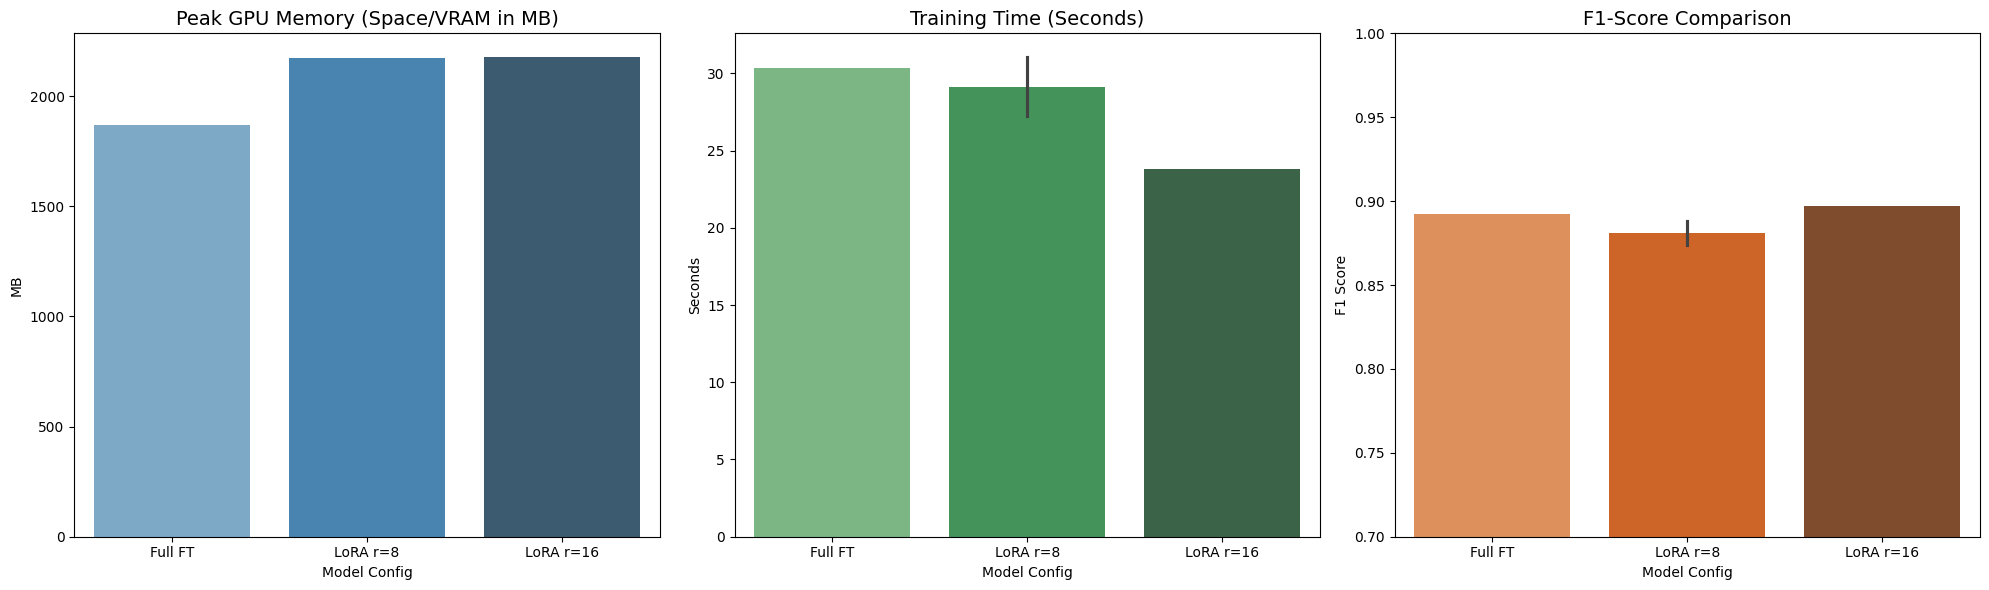


                               CONFUSION MATRICES                                         


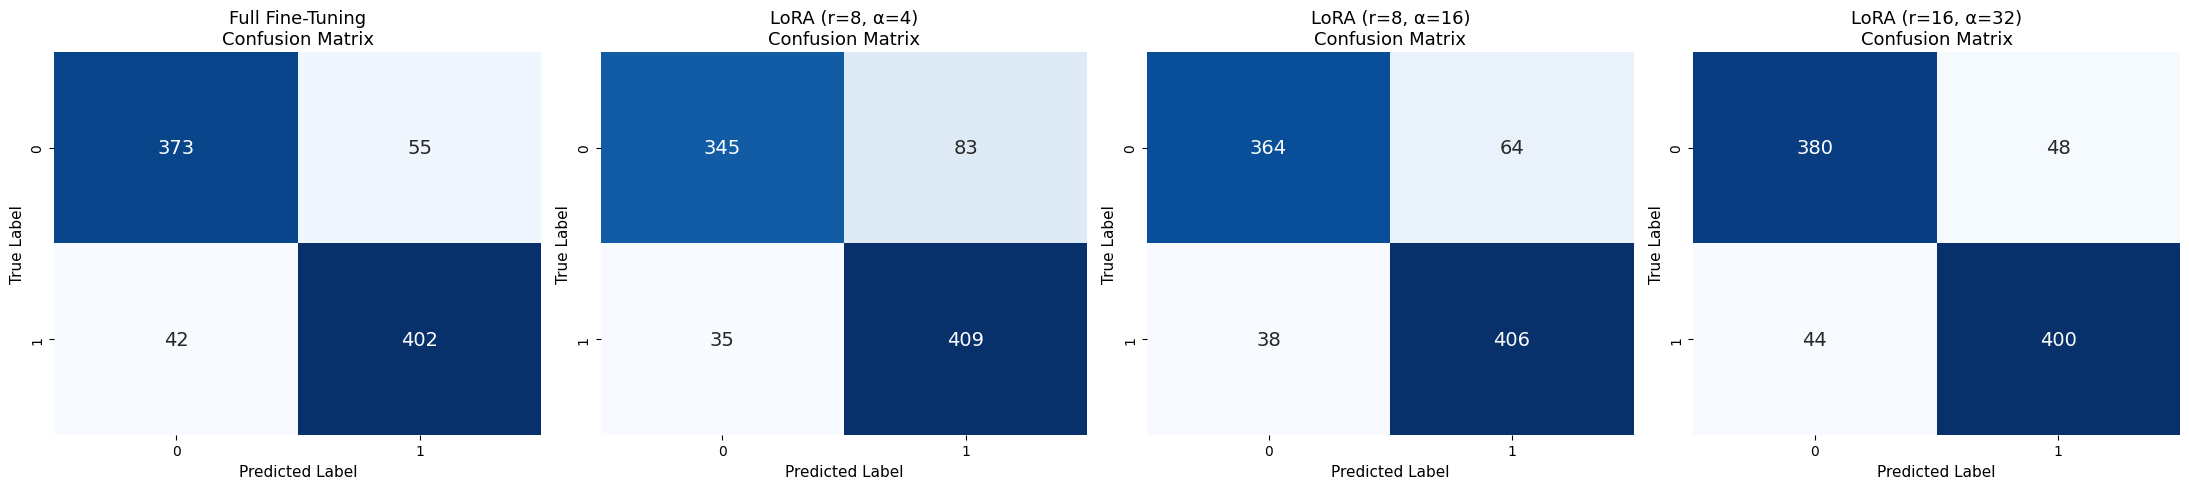

In [12]:
# ==========================================
# BLOCK 7: VISUAL COMPARISONS & CONFUSION MATRICES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the true labels from our validation dataset
labels_true = eval_dataset["label"]

# 1. Bar Charts: Memory, Training Time, and F1-Score
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Peak VRAM
sns.barplot(x="Model Config", y="Peak VRAM (MB)", data=df_results, ax=axes[0], palette="Blues_d")
axes[0].set_title("Peak GPU Memory (Space/VRAM in MB)", fontsize=14)
axes[0].set_ylabel("MB")

# Plot 2: Training Time
sns.barplot(x="Model Config", y="Training Time (s)", data=df_results, ax=axes[1], palette="Greens_d")
axes[1].set_title("Training Time (Seconds)", fontsize=14)
axes[1].set_ylabel("Seconds")

# Plot 3: F1-Score
sns.barplot(x="Model Config", y="F1-Score", data=df_results, ax=axes[2], palette="Oranges_d")
axes[2].set_title("F1-Score Comparison", fontsize=14)
axes[2].set_ylabel("F1 Score")
axes[2].set_ylim(0.7, 1.0) # Zoomed in to see the slight differences clearly

plt.tight_layout()
plt.show()

# 2. Confusion Matrices
print("\n" + "="*90)
print("                               CONFUSION MATRICES                                         ")
print("="*90)

# Combine Full FT predictions and LoRA predictions into one dictionary
all_preds = {"Full Fine-Tuning": full_preds, **lora_predictions}
fig, axes = plt.subplots(1, len(all_preds), figsize=(22, 5))

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(labels_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 14})
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=13)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.show()